Loan Default Prediction (Banking)

Step 1: Import Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Step 2: Load the Dataset

In [12]:
df = pd.read_csv("loan_default.csv")
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [13]:
print(df.head())

print(df.shape)

print(df.columns)

       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1      Full-time    

Step 3: Select Features and Target

In [14]:
target = "LoanAmount"    

X = df.drop(columns=[target])

y = df[target]

Step 4: Convert Categorical Data into numeric value

In [16]:
X = X.drop(
    columns=["LoanID", "CustomerID", "ApplicationID"],
    errors="ignore"
)

print(X.shape)

(255347, 16)


In [20]:
X = pd.get_dummies(X, drop_first=True)


In [21]:
X = X.astype(float)

y = y.astype(float)

print(X.dtypes)

Age                             float64
Income                          float64
CreditScore                     float64
MonthsEmployed                  float64
NumCreditLines                  float64
InterestRate                    float64
LoanTerm                        float64
DTIRatio                        float64
Default                         float64
Education_High School           float64
Education_Master's              float64
Education_PhD                   float64
EmploymentType_Part-time        float64
EmploymentType_Self-employed    float64
EmploymentType_Unemployed       float64
MaritalStatus_Married           float64
MaritalStatus_Single            float64
HasMortgage_Yes                 float64
HasDependents_Yes               float64
LoanPurpose_Business            float64
LoanPurpose_Education           float64
LoanPurpose_Home                float64
LoanPurpose_Other               float64
HasCoSigner_Yes                 float64
dtype: object


Step 5: Split the Dataset

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Step 6: Scale the Features

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Step 7: Train the Model Using Scikit-learn

In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Step 8: Display Model Parameters

In [26]:
print("Intercept")

print(model.intercept_)

print("Coefficients")

for name, coef in zip(X.columns, model.coef_):
    print(name, ":", coef)

Intercept
127547.49639460145
Coefficients
Age : 1023.880747661268
Income : 605.928642221825
CreditScore : 300.93982678484736
MonthsEmployed : 776.6963790465787
NumCreditLines : -163.78154760339717
InterestRate : -1116.3148165217128
LoanTerm : 154.65453207779515
DTIRatio : -1.21384182931996
Default : 6557.395212533163
Education_High School : -174.07867918451237
Education_Master's : 235.55425049788775
Education_PhD : 190.83761001653076
EmploymentType_Part-time : -220.59871491596917
EmploymentType_Self-employed : -126.4744069609853
EmploymentType_Unemployed : -74.19760728024569
MaritalStatus_Married : -9.353996190376275
MaritalStatus_Single : 95.62199411984025
HasMortgage_Yes : -6.954013587542553
HasDependents_Yes : 195.51402513838843
LoanPurpose_Business : -347.57866492652505
LoanPurpose_Education : -100.50743052546433
LoanPurpose_Home : 91.93184454475266
LoanPurpose_Other : -6.990192204248574
HasCoSigner_Yes : 131.038530907638


Step 9: Predict the Test Data

In [27]:
y_pred = model.predict(X_test)

Step 10: Evaluate the Model

In [28]:
print("MAE =", mean_absolute_error(y_test, y_pred))

print("MSE =", mean_squared_error(y_test, y_pred))

print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score =", r2_score(y_test, y_pred))

MAE = 61006.340741302236
MSE = 4966581637.494298
RMSE = 70473.97844236055
R2 Score = 0.0087153919703723


Step 11: Initialize Gradient Descent

In [29]:
X_train = np.array(X_train)

y_train = np.array(y_train)

m = len(y_train)

n = X_train.shape[1]

weights = np.zeros(n)

bias = 0

learning_rate = 0.01

epochs = 1000

loss_history = []

Step 12: Compute Predictions

In [30]:
y_prediction = np.dot(X_train, weights) + bias

Step 13: Calculate Error

In [31]:
error = y_prediction - y_train

Step 14: Calculate Loss Function

In [32]:
loss = np.mean(error ** 2)

Step 15: Calculate Gradients

In [33]:
dw = (2 / m) * np.dot(X_train.T, error)
db = (2 / m) * np.sum(error)

Step 16: Update Weights and Bias

In [34]:
weights = weights - learning_rate * dw

bias = bias - learning_rate * db

Step 17: Repeat for All Epochs

In [35]:
for epoch in range(epochs):

    y_prediction = np.dot(X_train, weights) + bias

    error = y_prediction - y_train

    loss = np.mean(error ** 2)

    loss_history.append(loss)

    dw = (2 / m) * np.dot(X_train.T, error)

    db = (2 / m) * np.sum(error)

    weights = weights - learning_rate * dw

    bias = bias - learning_rate * db

Step 18: Test the Gradient Descent Model

In [36]:
y_pred_gd = np.dot(X_test, weights) + bias

Step 19: Evaluate Gradient Descent

In [37]:
print("MAE =", mean_absolute_error(y_test, y_pred_gd))

print("MSE =", mean_squared_error(y_test, y_pred_gd))

print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred_gd)))

print("R2 Score =", r2_score(y_test, y_pred_gd))

MAE = 61006.34352889645
MSE = 4966582019.088288
RMSE = 70473.98114970012
R2 Score = 0.008715315807675927


Step 20: Plot the Loss Curve

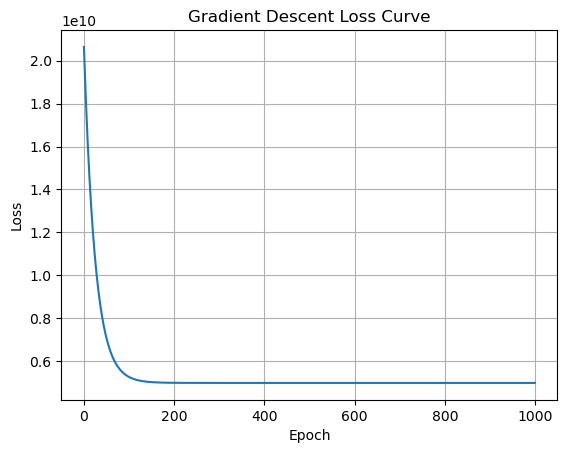

In [38]:
plt.plot(loss_history)

plt.title("Gradient Descent Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

Step 21: Compare Predictions

In [39]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Sklearn Prediction": y_pred,

    "Gradient Descent Prediction": y_pred_gd

})

print(comparison.head(20))

      Actual  Sklearn Prediction  Gradient Descent Prediction
0    92393.0       126878.961281                126879.337242
1   131575.0       125260.176649                125260.598442
2    75417.0       124168.966942                124169.357279
3    10804.0       123005.537845                123005.941088
4    21182.0       124180.139112                124180.531812
5   187008.0       124619.310944                124618.836991
6   159105.0       125406.706485                125407.400527
7   173967.0       125991.611658                125991.996883
8    41189.0       127510.754859                127511.144698
9   151275.0       124644.576254                124644.973684
10  178121.0       123959.814360                123958.987940
11  109990.0       123401.497019                123402.207425
12  166291.0       124334.901409                124335.308378
13  124620.0       124396.903490                124397.602213
14  222878.0       125206.079714                125206.476872
15  1123